In [2]:
import pandas as pd
import numpy as np
import sys
import random
import logomaker
import os
import logomaker
import matplotlib.pyplot as plt

In [3]:
this_path = os.getcwd()
sys.path.append('/home/gralak/NAS1/gralak/SmileSeq/')
import my_functions

In [4]:
dGG = pd.read_csv('/home/gralak/NAS2/gralak/SmileSeq_paper/SmileSeq_experiments/SmSAG01/04_ProBound_analysis/results/POU5F1_FL/binding_mode_size_12/POU5F1_FL_bindingmode_1.csv', index_col=0)

In [4]:
dGG

,A,C,G,T,m,g
0,0.075479,-0.769659,-0.388293,-0.555917,-0.643731,0.053818
1,0.564224,-0.696016,-0.934768,0.208310,-0.833453,-0.536600
2,0.361484,-1.036807,-1.792391,1.289472,-0.516075,-0.533987
3,2.217494,-2.679276,-1.258545,-0.436849,-0.093582,0.022454
4,-2.379278,-0.635955,-1.533037,2.211035,0.198523,-0.089591
5,-2.690974,-2.208062,2.445386,-0.084881,-0.091532,0.401759
6,-2.245453,0.638144,-1.222894,0.013256,1.308454,-0.719811
7,0.872398,-2.983426,-1.799093,0.505305,-0.390077,1.566589
8,1.379514,-0.216897,-0.768804,-1.657220,-0.235404,-0.729492
9,2.573395,-2.317726,-2.035315,-1.427998,0.345387,0.633953


In [5]:
# First get mu's
mean_values = dGG.max(axis=1)



dGG_m = dGG.add(-mean_values, axis='rows')



# ProBound uses ln
psam = np.e**(dGG_m)



# Now let's simulate the frequencies, creating the postion frequency matrix
pfm = psam
pfm = pfm.T

probs = my_functions.pfm_to_ppm(pfm)

In [6]:
probs.T

,A,C,G,T,m,g
0,0.246551,0.105893,0.155057,0.131128,0.120104,0.241267
1,0.358778,0.101744,0.080135,0.251335,0.088679,0.119328
2,0.212014,0.052371,0.024601,0.536270,0.088155,0.086590
3,0.758004,0.005663,0.023445,0.053322,0.075160,0.084407
4,0.007656,0.043765,0.017846,0.754333,0.100818,0.075581
5,0.004509,0.007309,0.767040,0.061085,0.060680,0.099376
6,0.014129,0.252602,0.039282,0.135223,0.493798,0.064966
7,0.245816,0.005201,0.016998,0.170288,0.069554,0.492144
8,0.592572,0.120068,0.069141,0.028438,0.117867,0.071914
9,0.776823,0.005836,0.007741,0.014208,0.083697,0.111695


In [7]:
mean_values = dGG.max(axis=1)



dGG_m = dGG.add(-mean_values, axis='rows')



# ProBound uses ln
psam = np.e**(dGG_m)



# Now let's simulate the frequencies, creating the postion frequency matrix
pfm = psam * 10000
pfm = pfm.T

probs = my_functions.pfm_to_ppm(pfm)

In [8]:
probs.T

,A,C,G,T
0,0.217104,0.276033,0.283025,0.223839
1,0.190618,0.454526,0.071124,0.283733
2,0.449205,0.175903,0.356369,0.018523
3,0.185533,0.287785,0.005523,0.521159
4,0.134409,0.240297,0.235546,0.389748
5,0.197199,0.252145,0.322577,0.228079
6,0.239539,0.266864,0.205379,0.288219
7,0.250913,0.289094,0.208398,0.251595
8,0.247245,0.279699,0.186211,0.286846
9,0.225628,0.275914,0.207296,0.291162


In [16]:
kat = pd.read_csv('/home/gralak/NAS1/gralak/SmileSeq/converted_to_pfm.csv', index_col=0)

In [17]:
kat

,A,C,G,T
0,0.217220,0.276170,0.282958,0.223651
1,0.190700,0.454679,0.070924,0.283696
2,0.449228,0.175908,0.356382,0.018482
3,0.185488,0.287842,0.005446,0.521224
4,0.134363,0.240175,0.235472,0.389990
5,0.197238,0.252125,0.322592,0.228045
6,0.239557,0.267047,0.205284,0.288111
7,0.250893,0.289135,0.208363,0.251608
8,0.247339,0.279631,0.186302,0.286728
9,0.225588,0.275837,0.207413,0.291162


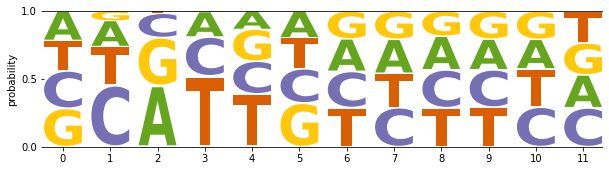

In [18]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])
logo = logomaker.Logo(probs.T,
                    ax=ax,
                    width=.8,
                    vpad=.05,
                    fade_probabilities=False,
                    stack_order='small_on_top',
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(spines=['left', 'right'], visible=False)


# style using Axes methods
logo.ax.set_ylabel('probability')
logo.ax.set_yticks([0, .5, 1])
logo.ax.set_xticks(range(len(probs.T)))


#fig.savefig(results_path + "ppm_logo.pdf", format='pdf')
#fig.savefig(results_path + "ppm_logo.png", format='png', dpi= 600)
plt.show()

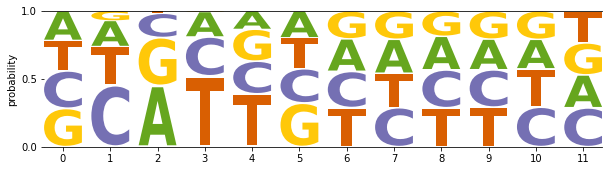

In [20]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])
logo = logomaker.Logo(kat,
                    ax=ax,
                    width=.8,
                    vpad=.05,
                    fade_probabilities=False,
                    stack_order='small_on_top',
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(spines=['left', 'right'], visible=False)


# style using Axes methods
logo.ax.set_ylabel('probability')
logo.ax.set_yticks([0, .5, 1])
logo.ax.set_xticks(range(len(probs.T)))


#fig.savefig(results_path + "ppm_logo.pdf", format='pdf')
#fig.savefig(results_path + "ppm_logo.png", format='png', dpi= 600)
plt.show()

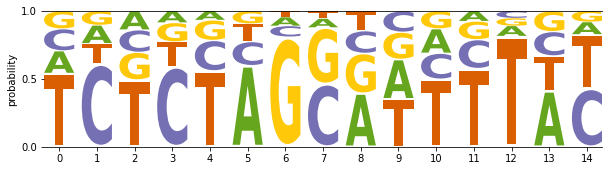

In [7]:
mean_values = dGG.max(axis=1)



dGG_m = dGG.add(-mean_values, axis='rows')



# ProBound uses ln
psam = np.e**(dGG_m)



# Now let's simulate the frequencies, creating the postion frequency matrix
pfm = psam * 10000
pfm = pfm.T

# TRYING TO DROP M and G since it makes it impossible to compare to other datasets
pfm = pfm.drop(['m', 'g'])

# Calculation of position probability matrix
probs = my_functions.pfm_to_ppm(pfm)

fig, ax = plt.subplots(1,1,figsize=[10,2.5])
logo = logomaker.Logo(probs.T,
                    ax=ax,
                    width=.8,
                    vpad=.05,
                    fade_probabilities=False,
                    stack_order='small_on_top',
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(spines=['left', 'right'], visible=False)


# style using Axes methods
logo.ax.set_ylabel('probability')
logo.ax.set_yticks([0, .5, 1])
logo.ax.set_xticks(range(len(probs.T)))


#fig.savefig(results_path + "ppm_logo.pdf", format='pdf')
#fig.savefig(results_path + "ppm_logo.png", format='png', dpi= 600)
plt.show()


In [8]:
dGG = pd.read_csv('/home/gralak/NAS2/gralak/SmileSeq_paper/SmileSeq_experiments/SmSAG15/04_ProBound_analysis/results/ZNF250_FL/binding_mode_size_12/ZNF250_FL_bindingmode_1.csv',  index_col=0)

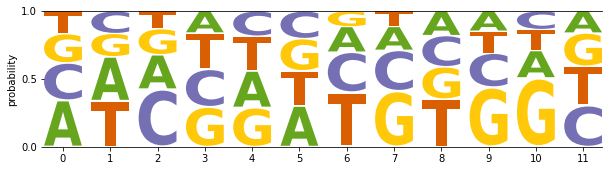

In [9]:
mean_values = dGG.max(axis=1)



dGG_m = dGG.add(-mean_values, axis='rows')



# ProBound uses ln
psam = np.e**(dGG_m)



# Now let's simulate the frequencies, creating the postion frequency matrix
pfm = psam * 10000
pfm = pfm.T

# TRYING TO DROP M and G since it makes it impossible to compare to other datasets
pfm = pfm.drop(['m', 'g'])

# Calculation of position probability matrix
probs = my_functions.pfm_to_ppm(pfm)

fig, ax = plt.subplots(1,1,figsize=[10,2.5])
logo = logomaker.Logo(probs.T,
                    ax=ax,
                    width=.8,
                    vpad=.05,
                    fade_probabilities=False,
                    stack_order='small_on_top',
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(spines=['left', 'right'], visible=False)


# style using Axes methods
logo.ax.set_ylabel('probability')
logo.ax.set_yticks([0, .5, 1])
logo.ax.set_xticks(range(len(probs.T)))


#fig.savefig(results_path + "ppm_logo.pdf", format='pdf')
#fig.savefig(results_path + "ppm_logo.png", format='png', dpi= 600)
plt.show()


In [21]:
# couple more to test

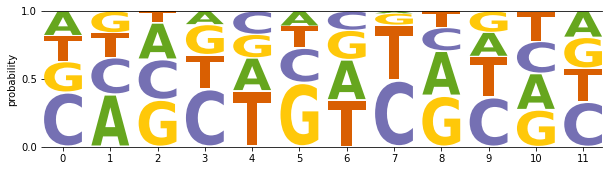

           A         C         G         T
0   0.181615  0.401506  0.225901  0.190978
1   0.386448  0.270590  0.160682  0.182280
2   0.269092  0.296959  0.346487  0.087462
3   0.099707  0.425519  0.222427  0.252347
4   0.243359  0.172458  0.172771  0.411412
5   0.110475  0.253842  0.472818  0.162865
6   0.297792  0.141960  0.216690  0.343558
7   0.018453  0.490820  0.084450  0.406278
8   0.329467  0.171597  0.376199  0.122736
9   0.176924  0.364826  0.157685  0.300565
10  0.267766  0.236353  0.272366  0.223515
11  0.194172  0.330543  0.227577  0.247708


In [45]:
dGG = pd.read_csv('/home/gralak/SVRAW1/gralak/grecobit/TOTEST_pfms/TOTEST_pfms/TOTEST_YWK_D_AffSeq_B12_MYF6__AFS_background_subsampled_trimmed__without_ns.probound_dgg.csv', index_col=0)
# First get mu's
mean_values = dGG.max(axis=1)



dGG_m = dGG.add(-mean_values, axis='rows')



# ProBound uses ln
psam = np.e**(dGG_m)



# Now let's simulate the frequencies, creating the postion frequency matrix
pfm = psam
pfm = pfm.T

probs = my_functions.pfm_to_ppm(pfm)



fig, ax = plt.subplots(1,1,figsize=[10,2.5])
logo = logomaker.Logo(probs.T,
                    ax=ax,
                    width=.8,
                    vpad=.05,
                    fade_probabilities=False,
                    stack_order='small_on_top',
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(spines=['left', 'right'], visible=False)


# style using Axes methods
logo.ax.set_ylabel('probability')
logo.ax.set_yticks([0, .5, 1])
logo.ax.set_xticks(range(len(probs.T)))


#fig.savefig(results_path + "ppm_logo.pdf", format='pdf')
#fig.savefig(results_path + "ppm_logo.png", format='png', dpi= 600)
plt.show()

print(probs.T)

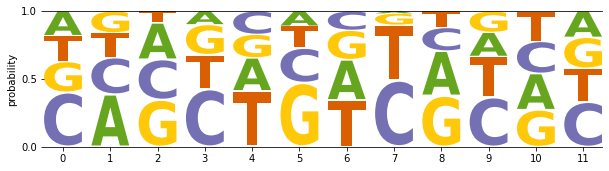

           A         C         G         T
0   0.181490  0.401663  0.225958  0.190889
1   0.386576  0.270639  0.160445  0.182340
2   0.269127  0.296886  0.346649  0.087339
3   0.099730  0.425539  0.222372  0.252358
4   0.243311  0.172315  0.172672  0.411702
5   0.110490  0.253864  0.472871  0.162775
6   0.297688  0.141980  0.216763  0.343569
7   0.018429  0.490887  0.084447  0.406237
8   0.329424  0.171438  0.376337  0.122801
9   0.176893  0.364909  0.157517  0.300682
10  0.267681  0.236502  0.272243  0.223574
11  0.194237  0.330464  0.227545  0.247754


In [46]:
kat = pd.read_csv('/home/gralak/SVRAW1/gralak/grecobit/TOTEST_pfms/TOTEST_pfms/TOTEST_YWK_D_AffSeq_B12_MYF6__AFS_background_subsampled_trimmed__without_ns.converted_to_pfm.csv', index_col=0)

fig, ax = plt.subplots(1,1,figsize=[10,2.5])
logo = logomaker.Logo(kat,
                    ax=ax,
                    width=.8,
                    vpad=.05,
                    fade_probabilities=False,
                    stack_order='small_on_top',
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(spines=['left', 'right'], visible=False)


# style using Axes methods
logo.ax.set_ylabel('probability')
logo.ax.set_yticks([0, .5, 1])
logo.ax.set_xticks(range(len(probs.T)))


#fig.savefig(results_path + "ppm_logo.pdf", format='pdf')
#fig.savefig(results_path + "ppm_logo.png", format='png', dpi= 600)
plt.show()

print(kat)

# ZNF716 bs2

In [5]:
df_bs2 = pd.read_csv('/home/gralak/NAS2/gralak/SmileSeq_paper/SmileSeq_experiments/SmSAG16/04_ProBound_analysis/results/ZNF716_FL/binding_mode_size_15/ZNF716_FL_bindingmode_2.csv', index_col=0)

In [6]:
# convert PSAM into PPM
    
# First get mu's
mean_values = df_bs2.max(axis=1)



df_bs2_m = df_bs2.add(-mean_values, axis='rows')



# ProBound uses ln
psam = np.e**(df_bs2_m)



# Now let's simulate the frequencies, creating the postion frequency matrix 
pfm = psam * 10000 #(this step is fully redundant and can be skipped)
pfm = pfm.T

In [7]:
# DROP M and G since it makes it impossible to compare to other datasets using standard tools
pfm = pfm.drop(['m', 'g'])

probs = my_functions.pfm_to_ppm(pfm)

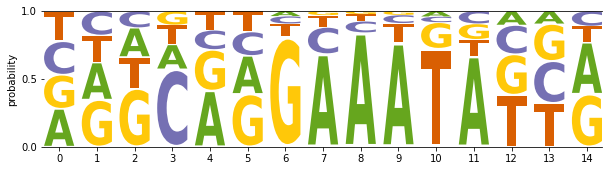

In [11]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])
logo = logomaker.Logo(probs.T,
                    ax=ax,
                    width=.8,
                    vpad=.05,
                    fade_probabilities=False,
                    stack_order='small_on_top',
                    color_scheme={'A':'#66a61e', 'C':'#7570b3','G':'#ffc809','T':'#d95f02','m':'#a6cee3'}
                    )
# style using Logo methods
logo.style_spines(spines=['left', 'right'], visible=False)


# style using Axes methods
logo.ax.set_ylabel('probability')
logo.ax.set_yticks([0, .5, 1])
logo.ax.set_xticks(range(len(probs.T)))


fig.savefig("ZNF716_FL/ZNF716_bs2_ppm_logo.pdf", format='pdf')
#fig.savefig(results_path + "ppm_logo.png", format='png', dpi= 600)
plt.show()